# 07. Revisión de hoteles unificados, registro provincial y precios

En este notebook se realiza la exploración unificada y comparativa de los tres conjuntos de datos principales de hoteles:
1. **Registro crudo provincial**: `data/raw/registre_turisme/hoteles_y_apartaments_turistics_provincia_barcelona.csv` (1.562 registros de la provincia).
2. **Censo unificado**: `data/processed/hoteles_y_apartaments_unificados.csv` (1.563 registros geolocalizados de la provincia, incluyendo hoteles y apartamentos turísticos).
3. **Hoteles con precio**: `data/processed/hoteles_con_precio.csv` (754 hoteles correspondientes exclusivamente al municipio de Barcelona).

## Objetivos del análisis
- Explicar y conciliar la discrepancia de registros entre el censo provincial (1.563) y la capa de precios (754).
- Verificar la disponibilidad de categorías/estrellas en el registro oficial.
- Analizar la relación entre categoría oficial, estrellas raspadas y distribución de precios.
- Preparar las variables para el posterior análisis de clustering de precios.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de gráficos
plt.style.use('ggplot')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# Rutas del proyecto (resolución dinámica e independiente del directorio de ejecución)
RAIZ = Path.cwd()
while not (RAIZ / 'data').exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
if not (RAIZ / 'data').exists():
    RAIZ = Path('../..')

RUTA_RAW = RAIZ / 'data' / 'raw' / 'registre_turisme' / 'hoteles_y_apartaments_turistics_provincia_barcelona.csv'
RUTA_UNIF = RAIZ / 'data' / 'processed' / 'hoteles_y_apartaments_unificados.csv'
RUTA_COMPLETO = RAIZ / 'data' / 'processed' / 'hoteles_unificados_y_precios.csv'

# Carga de datos directa desde data/processed
df_raw = pd.read_csv(RUTA_RAW)
df_unif = pd.read_csv(RUTA_UNIF)
df_completo = pd.read_csv(RUTA_COMPLETO)

print(f'Registros en raw provincial: {len(df_raw)}')
print(f'Registros en unificados provincial: {len(df_unif)}')
print(f'Registros en dataset unificado con precio (data/processed): {len(df_completo)}')
print(f'Establecimientos con precio asignado: {df_completo["precio"].notna().sum()}')

Registros en raw provincial: 1562
Registros en unificados provincial: 1563
Registros en dataset unificado con precio (data/processed): 1563
Establecimientos con precio asignado: 476


## 1. Explicación de la diferencia de registros entre datasets
El registro oficial provincial contiene todos los establecimientos de la provincia de Barcelona. La capa de precios `hoteles_con_precio.csv` se centra específicamente en los **hoteles del municipio de Barcelona**.

In [8]:
# Comparación de municipios en unificados vs hoteles con precio
resumen_municipios = df_unif['municipio'].value_counts().head(10).to_frame('total_provincia')
print('Top municipios en el censo provincial:')
display(resumen_municipios)

# Filtrar el censo unificado solo para Barcelona municipio
df_unif_bcn = df_unif[df_unif['municipio'] == 'Barcelona']
print(f'Total establecimientos en censo unificado en Barcelona ciudad: {len(df_unif_bcn)}')
print('Desglose por tipo en Barcelona ciudad:')
display(df_unif_bcn['tipo'].value_counts())

Top municipios en el censo provincial:


,total_provincia
municipio,
Barcelona,768
Sitges,64
Castelldefels,54
"Hospitalet de Llobregat, l'",50
Calella,46
Malgrat de Mar,25
Badalona,25
Santa Susanna,23
Pineda de Mar,19


Total establecimientos en censo unificado en Barcelona ciudad: 768
Desglose por tipo en Barcelona ciudad:


tipo
hotel                  754
apartament_turistic     13
Name: count, dtype: int64

## 2. Categorías oficiales de estrellas en el registro
El registro oficial de turismo de la Generalitat **sí incluye la clasificación oficial por estrellas** en la columna `categoria`.

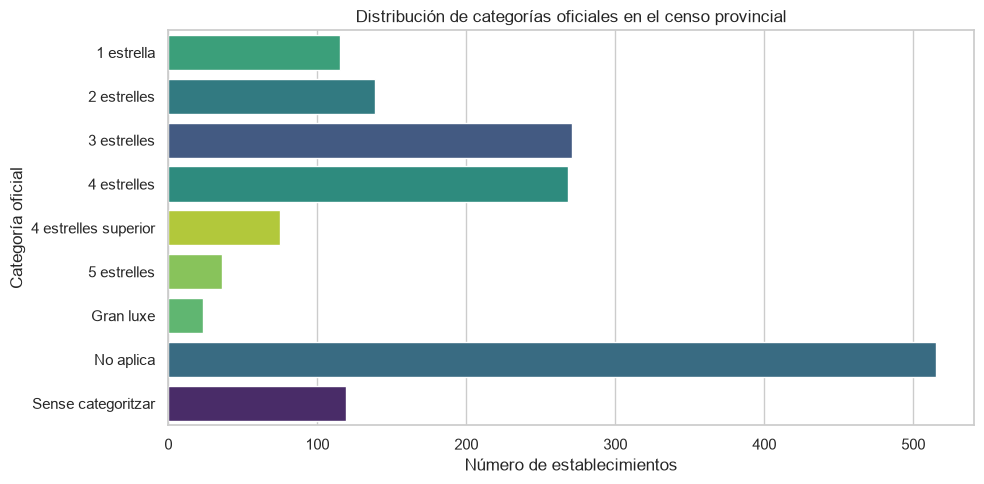

Frecuencia detallada por categoría:


categoria
No aplica               515
3 estrelles             271
4 estrelles             268
2 estrelles             139
Sense categoritzar      119
1 estrella              115
4 estrelles superior     75
5 estrelles              36
Gran luxe                23
4 claus                   1
Name: count, dtype: int64

In [9]:
# Distribución de categorías oficiales en el censo unificado
plt.figure(figsize=(10, 5))
order = ['1 estrella', '2 estrelles', '3 estrelles', '4 estrelles', '4 estrelles superior', '5 estrelles', 'Gran luxe', 'No aplica', 'Sense categoritzar']
sns.countplot(data=df_unif, y='categoria', hue='categoria', order=[c for c in order if c in df_unif['categoria'].unique()], palette='viridis', legend=False)
plt.title('Distribución de categorías oficiales en el censo provincial')
plt.xlabel('Número de establecimientos')
plt.ylabel('Categoría oficial')
plt.tight_layout()
plt.show()

print('Frecuencia detallada por categoría:')
display(df_unif['categoria'].value_counts())

## 3. Unificación y cruce del censo con la capa de precios
Unimos el censo unificado con el fichero de precios para disponer en un único DataFrame de los datos administrativos, la localización y los precios/estrellas del raspado.

In [10]:
# Verificación directa del dataset procesado consolidado
print(f'Dimensiones del dataset unificado completo: {df_completo.shape}')
print(f'Hoteles con precio asignado: {df_completo["precio"].notna().sum()}')
display(df_completo.head())

Dimensiones del dataset unificado completo: (1563, 30)
Hoteles con precio asignado: 476


,licencia_id,nombre_comercial,municipio,codi_ine,comarca,tipo_via,nombre_via,numero,codigo_postal,categoria,plazas,habitaciones,nif,razon_social,tipo,es_persona_fisica,lat,lon,metodo_match,similitud_nombre,piso,puerta,coordenada_compartida,nivel_geo,precio,moneda,estrellas_raspadas,puntuacion,metodo_cruce,similitud
0,ATB-000001,Atenea Calabria,Barcelona,80193.0,Barcelonès,Carrer,Calabria,129,8015.0,Sense categoritzar,160.0,80.0,A08115669,"TEXFIL GANDUXER ALUM, SA",apartament_turistic,False,NaN,NaN,solo_registre,NaN,NaN,NaN,False,municipio,NaN,NaN,NaN,NaN,NaN,NaN
1,ATB-000002,Voramar,Castelldefels,80569.0,Baix Llobregat,Carrer,Barques,2,8860.0,Sense categoritzar,36.0,18.0,B63470942,"CASTELLISCON, SL",apartament_turistic,False,NaN,NaN,solo_registre,NaN,NaN,NaN,False,municipio,NaN,NaN,NaN,NaN,NaN,NaN
2,ATB-000003,Gutenberg,Barcelona,80193.0,Barcelonès,Passatge,Gutenberg,7,8001.0,Sense categoritzar,170.0,85.0,A08433989,"APARTAMENTOS GUTENBERG, SA",apartament_turistic,False,NaN,NaN,solo_registre,NaN,NaN,NaN,False,municipio,NaN,NaN,NaN,NaN,NaN,NaN
3,ATB-000004,Montserrat,Sitges,82704.0,Garraf,Carrer,Antoni Gaudí,11,8870.0,Sense categoritzar,12.0,6.0,NaN,NaN,apartament_turistic,True,NaN,NaN,solo_registre,NaN,NaN,NaN,False,municipio,NaN,NaN,NaN,NaN,NaN,NaN
4,ATB-000005,Silver,Barcelona,80193.0,Barcelonès,Carrer,Breton de los Herreros,26,8012.0,Sense categoritzar,98.0,49.0,A08139859,"PROYECTOS E INMUEBLES, S. A",apartament_turistic,False,NaN,NaN,solo_registre,NaN,NaN,NaN,False,municipio,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Análisis de precios por categoría hotelera
Revisión de la distribución de precios en euros según la categoría oficial de estrellas.

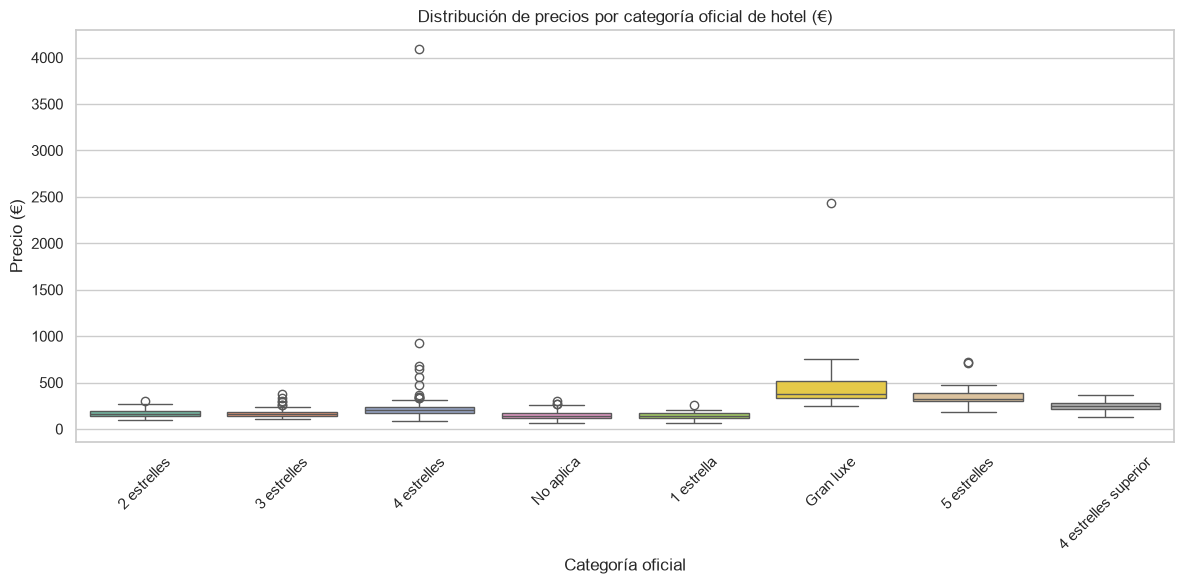

,count,mean,median,std,min,max
categoria,,,,,,
1 estrella,30,143.77,140.26,41.06,63.57,263.50
2 estrelles,29,166.91,159.74,45.66,99.10,299.00
3 estrelles,101,170.85,161.83,44.60,105.26,375.18
4 claus,0,NaN,NaN,NaN,NaN,NaN
4 estrelles,122,254.80,200.94,366.12,90.49,4090.48
4 estrelles superior,30,245.73,242.96,51.26,133.80,369.00
5 estrelles,19,373.73,324.72,138.87,179.93,717.66
Gran luxe,18,525.04,379.04,495.40,248.56,2438.50
No aplica,127,147.49,144.00,43.93,66.28,302.02


In [11]:
# Distribución de precio por categoría oficial
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_completo[df_completo['precio'].notna()],
    x='categoria',
    y='precio',
    hue='categoria',
    palette='Set2',
    legend=False
)
plt.xticks(rotation=45)
plt.title('Distribución de precios por categoría oficial de hotel (€)')
plt.xlabel('Categoría oficial')
plt.ylabel('Precio (€)')
plt.tight_layout()
plt.show()

# Resumen estadístico del precio por categoría
resumen_precios = df_completo.groupby('categoria')['precio'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2)
display(resumen_precios)

## 5. Preparación para el clustering de hoteles y precios
Selección de variables cuantitativas y cualitativas necesarias para agrupar (clusterizar) la oferta hotelera por rango de precio, capacidad y categoría.

Registros completos listos para clustering: 432


,plazas,habitaciones,precio,estrellas_raspadas,puntuacion
count,432.00,432.00,432.00,432.00,432.00
mean,144.66,76.40,211.66,3.24,4.25
std,153.99,78.16,238.78,1.07,0.57
min,4.00,2.00,63.57,1.00,2.50
25%,39.75,21.00,141.61,2.00,4.10
50%,100.00,57.50,171.84,3.00,4.30
75%,180.50,94.75,217.45,4.00,4.40
max,1012.00,494.00,4090.48,5.00,9.00


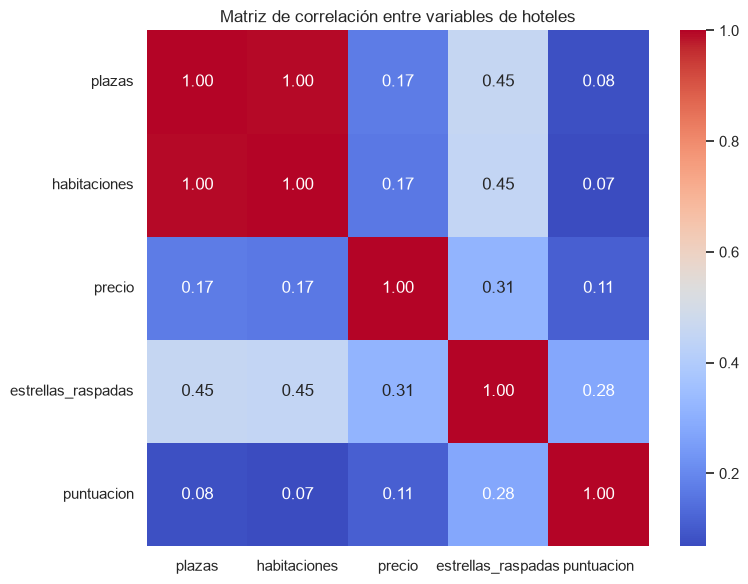

In [12]:
# Selección de variables para análisis numérico y clustering
vars_clustering = ['plazas', 'habitaciones', 'precio', 'estrellas_raspadas', 'puntuacion']
df_cluster_base = df_completo[vars_clustering].dropna()

print(f'Registros completos listos para clustering: {len(df_cluster_base)}')
display(df_cluster_base.describe().round(2))

# Matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(df_cluster_base.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación entre variables de hoteles')
plt.tight_layout()
plt.show()